In [19]:
import pandas as pd

In [20]:
files = [
    "C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-01.parquet",
    #"C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-02.parquet",
    #"C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-03.parquet"
]

df = pd.concat([
    pd.read_parquet(file)
    for file in files
])

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                     
---  ------        --------------  -----                     
 0   subreddit     1041 non-null   str                       
 1   created_at    1041 non-null   datetime64[ns, US/Central]
 2   retrieved_at  1041 non-null   datetime64[ns, US/Central]
 3   type          1041 non-null   str                       
 4   text          1041 non-null   str                       
 5   score         1041 non-null   int64                     
 6   post_id       1041 non-null   str                       
 7   parent_id     844 non-null    str                       
dtypes: datetime64[ns, US/Central](2), int64(1), str(5)
memory usage: 464.2 KB


In [22]:
df.columns

Index(['subreddit', 'created_at', 'retrieved_at', 'type', 'text', 'score',
       'post_id', 'parent_id'],
      dtype='str')

In [23]:
df.head()

,subreddit,created_at,retrieved_at,type,text,score,post_id,parent_id
0,artificial,2025-05-01 10:46:37-05:00,2025-05-01 18:22:20.660913-05:00,post,Incredible. After being pressed for a source f...,147,1kcbzf3,NaN
1,artificial,2025-05-01 10:55:08-05:00,2025-05-01 18:22:20.660913-05:00,comment,So has it read this on a forum or something an...,34,mq1d76o,t3_1kcbzf3
2,artificial,2025-05-01 11:33:51-05:00,2025-05-01 18:22:20.660913-05:00,comment,Hallucinations are the one speed-brake that is...,16,mq1kzk8,t3_1kcbzf3
3,artificial,2025-05-01 13:01:07-05:00,2025-05-01 18:22:20.660913-05:00,comment,LLMs don’t know the world exists outside of wo...,11,mq23924,t3_1kcbzf3
4,artificial,2025-05-01 14:13:54-05:00,2025-05-01 18:22:20.660913-05:00,comment,"Stop using LLMs as fact machines, they are not...",10,mq2i16c,t3_1kcbzf3


In [24]:
df.isnull().sum()

subreddit         0
created_at        0
retrieved_at      0
type              0
text              0
score             0
post_id           0
parent_id       197
dtype: int64

In [25]:
df.describe(include="all")

,subreddit,created_at,retrieved_at,type,text,score,post_id,parent_id
count,1041,1041,1041,1041,1041,1041.000000,1041,844
unique,4,NaN,NaN,2,1036,NaN,1041,168
top,LocalLLaMA,NaN,NaN,comment,"Feels sci-fi to watch it ""zoom and enhance"" wh...",NaN,1kcbzf3,t3_1kcbzf3
freq,523,NaN,NaN,844,3,NaN,1,10
mean,NaN,2025-05-01 08:27:04.967339008-05:00,2025-05-01 18:22:39.930800640-05:00,NaN,NaN,25.522574,NaN,NaN
min,NaN,2025-04-30 18:10:44-05:00,2025-05-01 18:22:20.660913-05:00,NaN,NaN,-41.000000,NaN,NaN
25%,NaN,2025-05-01 03:04:04-05:00,2025-05-01 18:22:26.071697920-05:00,NaN,NaN,1.000000,NaN,NaN
50%,NaN,2025-05-01 10:29:08-05:00,2025-05-01 18:22:26.071697920-05:00,NaN,NaN,3.000000,NaN,NaN
75%,NaN,2025-05-01 13:29:33-05:00,2025-05-01 18:22:53.001740032-05:00,NaN,NaN,12.000000,NaN,NaN
max,NaN,2025-05-01 18:22:03-05:00,2025-05-01 18:23:06.503195-05:00,NaN,NaN,2304.000000,NaN,NaN


In [26]:
df.shape

(1041, 8)

EDA

Post vs comment

In [33]:
df["type"].value_counts()

type
comment    844
post       197
Name: count, dtype: int64

No of subreddits

In [34]:
df["subreddit"].nunique()

4

In [35]:
df["subreddit"].value_counts().head(20)

subreddit
LocalLLaMA     523
OpenAI         227
singularity    211
artificial      80
Name: count, dtype: int64

Data/Time Range

In [36]:
print("Start:", df["created_at"].min())
print("End:", df["created_at"].max())

Start: 2025-04-30 18:10:44-05:00
End: 2025-05-01 18:22:03-05:00


Score Statistics

In [38]:
df["score"].describe()

count    1041.000000
mean       25.522574
std       112.633108
min       -41.000000
25%         1.000000
50%         3.000000
75%        12.000000
max      2304.000000
Name: score, dtype: float64

Duplicate Records

In [39]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate post IDs:", df["post_id"].duplicated().sum())

Duplicate rows: 0
Duplicate post IDs: 0


Text Lenght

In [40]:
df["text_length"] = df["text"].str.len()

df["text_length"].describe()

count    1041.000000
mean      359.771374
std       662.831590
min         2.000000
25%        63.000000
50%       152.000000
75%       378.000000
max      9758.000000
Name: text_length, dtype: float64

Visualization

<Axes: title={'center': 'Posts vs Comments'}, xlabel='type'>

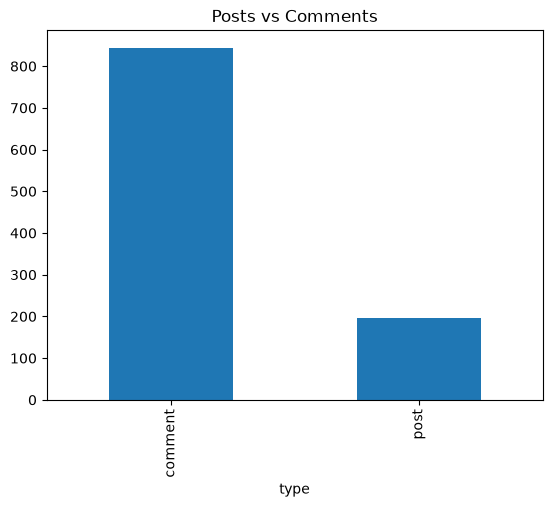

In [41]:
df["type"].value_counts().plot(kind="bar", title="Posts vs Comments")

<Axes: title={'center': 'Distribution of Reddit Scores'}, ylabel='Frequency'>

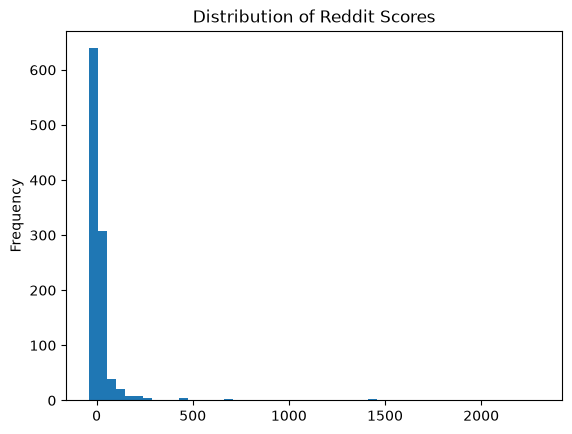

In [ ]:
df["score"].plot(kind="hist", bins=50, title="Distribution of Reddit Scores")

Concating all 3 files

In [44]:
files = [
    "C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-01.parquet",
    "C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-02.parquet",
    "C:/Users/praharshaanugu/MLprojects/social-media-trend-analyser/data/raw/2025-05-03.parquet"
]

dfs = [pd.read_parquet(file) for file in files]
df_all = pd.concat(dfs, ignore_index=True)

print(df_all.shape)

(2902, 8)


In [45]:
df_all["created_at"].min(), df_all["created_at"].max()

(Timestamp('2025-04-30 18:10:44-0500', tz='US/Central'),
 Timestamp('2025-05-03 18:21:10-0500', tz='US/Central'))

In [46]:
df_all["type"].value_counts()

type
comment    2393
post        509
Name: count, dtype: int64

In [47]:
df_all.groupby(
    df_all["created_at"].dt.date
).size()

created_at
2025-04-30     163
2025-05-01    1014
2025-05-02     876
2025-05-03     849
dtype: int64

Daily Actitviy

In [48]:
daily_counts = (
    df_all
    .groupby(df_all["created_at"].dt.date)
    .size()
)

daily_counts

created_at
2025-04-30     163
2025-05-01    1014
2025-05-02     876
2025-05-03     849
dtype: int64

Posts vs comments per day

In [49]:
daily_type = pd.crosstab(
    df_all["created_at"].dt.date,
    df_all["type"]
)

daily_type

type,comment,post
created_at,,
2025-04-30,121,42
2025-05-01,824,190
2025-05-02,724,152
2025-05-03,724,125


Subreddit activity per day

In [50]:
daily_subreddit = pd.crosstab(
    df_all["created_at"].dt.date,
    df_all["subreddit"]
)

daily_subreddit

subreddit,LocalLLaMA,OpenAI,artificial,singularity
created_at,,,,
2025-04-30,96,26,17,24
2025-05-01,471,265,66,212
2025-05-02,378,238,46,214
2025-05-03,359,239,53,198


14 files

In [51]:
from pathlib import Path

files = sorted(Path("../data/raw").glob("*.parquet"))

print("Number of files:", len(files))

for file in files:
    print(file.name)

Number of files: 14
2025-05-01.parquet
2025-05-02.parquet
2025-05-03.parquet
2025-05-04.parquet
2025-05-05.parquet
2025-05-06.parquet
2025-05-07.parquet
2025-05-08.parquet
2025-05-09.parquet
2025-05-10.parquet
2025-05-11.parquet
2025-05-12.parquet
2025-05-13.parquet
2025-05-14.parquet


In [52]:
dfs = [pd.read_parquet(file) for file in files]

df_all = pd.concat(dfs, ignore_index=True)

print("Shape:", df_all.shape)

Shape: (12626, 8)


Checking Time range

In [53]:
print("Start:", df_all["created_at"].min())
print("End:", df_all["created_at"].max())

Start: 2025-04-30 18:10:44-05:00
End: 2025-05-14 18:22:00-05:00


checking activity by day

In [54]:
daily_counts = (
    df_all
    .groupby(df_all["created_at"].dt.date)
    .size()
)

daily_counts

created_at
2025-04-30     163
2025-05-01    1014
2025-05-02     876
2025-05-03     985
2025-05-04     789
2025-05-05     950
2025-05-06    1043
2025-05-07     822
2025-05-08     917
2025-05-09     935
2025-05-10     806
2025-05-11     741
2025-05-12     864
2025-05-13     859
2025-05-14     862
dtype: int64

Plots

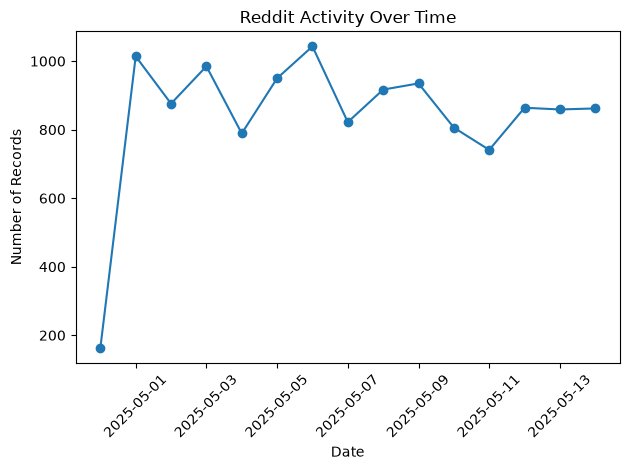

In [55]:
import matplotlib.pyplot as plt

daily_counts.plot(
    kind="line",
    marker="o",
    title="Reddit Activity Over Time",
    xlabel="Date",
    ylabel="Number of Records"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Lets seperate posts and comments

In [56]:
daily_type = pd.crosstab(
    df_all["created_at"].dt.date,
    df_all["type"]
)

daily_type

type,comment,post
created_at,,
2025-04-30,121,42
2025-05-01,824,190
2025-05-02,724,152
2025-05-03,823,162
2025-05-04,661,128
2025-05-05,790,160
2025-05-06,858,185
2025-05-07,680,142
2025-05-08,769,148


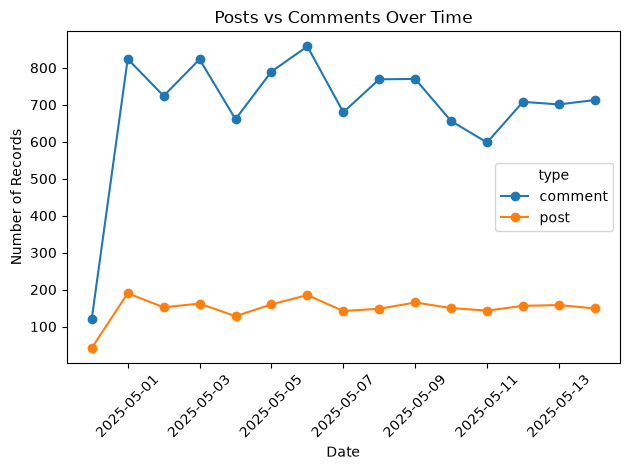

In [57]:
daily_type.plot(
    kind="line",
    marker="o",
    title="Posts vs Comments Over Time",
    xlabel="Date",
    ylabel="Number of Records"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
daily_subreddit = pd.crosstab(
    df_all["created_at"].dt.date,
    df_all["subreddit"]
)

daily_subreddit

subreddit,LocalLLaMA,OpenAI,artificial,singularity
created_at,,,,
2025-04-30,96,26,17,24
2025-05-01,471,265,66,212
2025-05-02,378,238,46,214
2025-05-03,429,292,57,207
2025-05-04,303,230,56,200
2025-05-05,466,247,36,201
2025-05-06,410,270,104,259
2025-05-07,324,217,96,185
2025-05-08,345,295,47,230


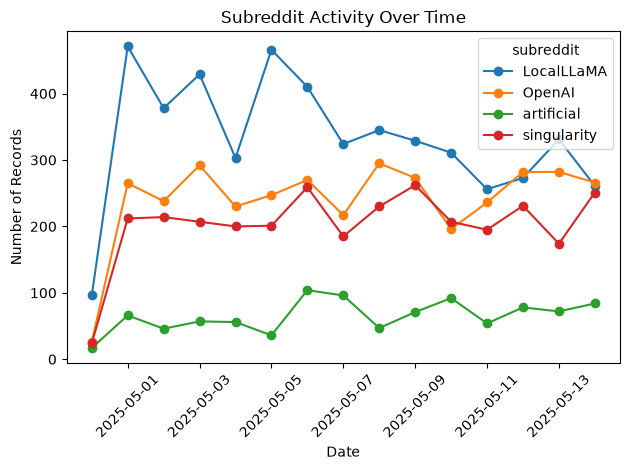

In [59]:
daily_subreddit.plot(
    kind="line",
    marker="o",
    title="Subreddit Activity Over Time",
    xlabel="Date",
    ylabel="Number of Records"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
pd.set_option("display.max_colwidth", 300)

df_all[[
    "created_at",
    "subreddit",
    "type",
    "text",
    "score"
]].head(20)

,created_at,subreddit,type,text,score
0,2025-05-01 10:46:37-05:00,artificial,post,"Incredible. After being pressed for a source for a claim, o3 claims it personally overheard someone say it at a conference in 2018:\n\n",147
1,2025-05-01 10:55:08-05:00,artificial,comment,So has it read this on a forum or something and repeating or just flat out hallucination,34
2,2025-05-01 11:33:51-05:00,artificial,comment,Hallucinations are the one speed-brake that is keeping AI from taking over entire industries. In a way we're all kinda lucky because it gives us time to adjust.\n\nImagine if these things came out of the gate with a 1% hallucination rate?,16
3,2025-05-01 13:01:07-05:00,artificial,comment,LLMs don’t know the world exists outside of words about it.,11
4,2025-05-01 14:13:54-05:00,artificial,comment,"Stop using LLMs as fact machines, they are not that. Use them to produce deliverable elements of work that generate revenue for you. ""lies"" suggests it has intent, it doesn't. Its just guessing the next most likely word someone else would say in response to what you asked.",10
5,2025-05-01 14:37:18-05:00,artificial,comment,https://preview.redd.it/0uz86wqq38ye1.jpeg?width=519&format=pjpg&auto=webp&s=24159d028e9eea51a7b08cee6baca7939439905a,2
6,2025-05-01 13:57:01-05:00,artificial,comment,4o has been doing this to me several times a day as well,1
7,2025-05-01 14:16:15-05:00,artificial,comment,🤣🤣🤣,1
8,2025-05-01 15:17:44-05:00,artificial,comment,"Yep.. some of the AI results from chrome search are just purely incorrect and even illogical at a base level. Easy to manipulate the LLM to say pretty much what you want. It’s pretty simple garbage in garbage out, trained on redit posts :D",1
9,2025-05-01 15:20:23-05:00,artificial,comment,"The real news is that people have begun to trust LLMs so much that they're outraged when they hallucinate.\n\nIt says a lot about how far they've come, and how quickly our expectations adjusted. Nobody would have batted an eye at this a year ago.",1


In [61]:
df_all["text"].sample(20, random_state=42)

7058                                                                                                             Dude, I'm desperately holding on to my youth so that I can hold out for the good rejuvenation shit.\n\nI mean, I still look great, but I've got full blown hip arthritis and terrible haemorrhoids.
6876                                                                                                                                                                                                                                 Yes, barely. You'll have to load a lot of the model into RAM and it'll be slow.
4862                                                                                                              Nvidia Nemotron and IBM Granite models are always a hard pass for me.    The benchmarks are always mouth watering, but they just never come close.   I hope it's just me, what are we doing wrong?
5470                                                                     

Text Processing

Make a copy

In [62]:
df_text = df_all.copy()

Inspect Problamatic text

In [63]:
print("Total records:", len(df_text))

print("Empty texts:", df_text["text"].isna().sum())

print("Very short texts (<20 chars):",
      (df_text["text"].str.len() < 20).sum())

print("Very long texts (>5000 chars):",
      (df_text["text"].str.len() > 5000).sum())

Total records: 12626
Empty texts: 0
Very short texts (<20 chars): 728
Very long texts (>5000 chars): 54


Cleaning function

In [64]:
import re

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove Reddit/Markdown links
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)

    # Remove markdown formatting
    text = re.sub(r'[*_~`]', ' ', text)

    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [65]:
df_text["clean_text"] = df_text["text"].apply(clean_text)

In [66]:
df_text[["text", "clean_text"]].sample(
    15,
    random_state=42
)

,text,clean_text
7058,"Dude, I'm desperately holding on to my youth so that I can hold out for the good rejuvenation shit.\n\nI mean, I still look great, but I've got full blown hip arthritis and terrible haemorrhoids.","Dude, I'm desperately holding on to my youth so that I can hold out for the good rejuvenation shit. I mean, I still look great, but I've got full blown hip arthritis and terrible haemorrhoids."
6876,"Yes, barely. You'll have to load a lot of the model into RAM and it'll be slow.","Yes, barely. You'll have to load a lot of the model into RAM and it'll be slow."
4862,"Nvidia Nemotron and IBM Granite models are always a hard pass for me. The benchmarks are always mouth watering, but they just never come close. I hope it's just me, what are we doing wrong?","Nvidia Nemotron and IBM Granite models are always a hard pass for me. The benchmarks are always mouth watering, but they just never come close. I hope it's just me, what are we doing wrong?"
5470,Looks like it can still generate reddit posts,Looks like it can still generate reddit posts
7407,"Historical/Religious bias is wild\n\nI learned today that ChatGPT has an extreme response to being asked about history and religion for some reason. \n\nMy use case: I asked about Dionysus, and related rituals. It began to flat-out tell me that it was against it's guidelines to talk in detail ab...","Historical/Religious bias is wild I learned today that ChatGPT has an extreme response to being asked about history and religion for some reason. My use case: I asked about Dionysus, and related rituals. It began to flat-out tell me that it was against it's guidelines to talk in detail about the..."
6720,"a pentium 2 is vintage, not modest hardware.\n\n\ngo a little newer for PCIE and gg, you can cheat with llama.cpp and a modern GPU, no need for 230 thousand params models. \nkepler supports win2k, and maxwell supports winxp and maybe 2k. 2x M6000s (or 1 m6000 and 1 m40) and you've got the ultima...","a pentium 2 is vintage, not modest hardware. go a little newer for PCIE and gg, you can cheat with llama.cpp and a modern GPU, no need for 230 thousand params models. kepler supports win2k, and maxwell supports winxp and maybe 2k. 2x M6000s (or 1 m6000 and 1 m40) and you've got the ultimate vint..."
724,"r/BuyFromEU say no to blackmail, take a stance!","r/BuyFromEU say no to blackmail, take a stance!"
8769,Why was the last one blocked?,Why was the last one blocked?
2608,"Is there a path for AI to advance to more complex conversations beyond the singular input-output text?\n\nI wonder if we will have an AI that can:\n\nRecognize multiple faces and voices\n\nHear when multiple people are talking at once and admit confusion if it's present, rather than take a singu...","Is there a path for AI to advance to more complex conversations beyond the singular input-output text? I wonder if we will have an AI that can: Recognize multiple faces and voices Hear when multiple people are talking at once and admit confusion if it's present, rather than take a singular input..."
12470,In order to get it to think for longer (longer isn’t always better) you must prompt it in a way that it uses one of its tools,In order to get it to think for longer (longer isn’t always better) you must prompt it in a way that it uses one of its tools


In [67]:
df_posts = df_text[df_text["type"] == "post"].copy()

print("Total posts:", len(df_posts))

Total posts: 2230


In [68]:
df_posts = df_posts[
    df_posts["clean_text"].str.len() >= 30
].copy()

print("Posts after length filtering:", len(df_posts))

Posts after length filtering: 2158


In [69]:
df_posts[[
    "created_at",
    "subreddit",
    "text",
    "score"
]].sample(30, random_state=42)

,created_at,subreddit,text,score
6001,2025-05-07 14:15:23-05:00,LocalLLaMA,"Trying out the Ace-Step Song Generation Model\n\nSo, I got Gemini to whip up some lyrics for an alphabet song, and then I used ACE-Step-v1-3.5B to generate a rock-style track at 105bpm. \n \nGive it a listen – how does it sound to you?\n\nMy feeling is that some of the transitions are still a ...",18
2064,2025-05-03 06:00:49-05:00,LocalLLaMA,Teaching LLMs to use tools with RL! Successfully trained 0.5B/3B Qwen models to use a calculator tool 🔨\n\n**👋 I recently had great fun training small language models (Qwen2.5 0.5B & 3B) to use a slightly complex calculator syntax through multi-turn reinforcement learning. Results were pretty co...,82
2398,2025-05-03 10:36:51-05:00,LocalLLaMA,"The GPT-4o sycophancy saga seems to be a case against open-source decentralized models?\n\nCorrect me if I am wrong, but it seems to me that much of the damage in this case could be mitigated because GPT-4o was a closed-source centralized model? One rollback and boom, no one on earth has access ...",0
6642,2025-05-08 07:55:52-05:00,LocalLLaMA,"Smoothie Qwen: A lightweight adjustment tool for smoothing token probabilities in the Qwen models to encourage balanced multilingual generation.\n\n**Smoothie Qwen** is a lightweight adjustment tool that smooths token probabilities in Qwen models, enhancing balanced multilingual generation capab...",85
2866,2025-05-03 03:51:57-05:00,OpenAI,Cam someone help me?\n\nCam someone gimme a graph that shows the real life AI growth from 2020 to 2030 ? Or even website links too ?\n\nAnd it need not to be about ai ..If you have graphs that show our technological improvements share it !!\n\nPlease 🙏,0
6744,2025-05-08 05:11:47-05:00,LocalLLaMA,"Anyone get speculative decoding to work for Qwen 3 on LM Studio?\n\nI got it working in llama.cpp, but it's being slower than running Qwen 3 32b by itself in LM Studio. Anyone tried this out yet?",22
8688,2025-05-10 06:19:48-05:00,LocalLLaMA,"Building a local system\n\nHi everybody\n\nI'd like to build a local system with the following elements:\n\n* A good model for pdf -> markdown tasks, basically being able to read pages with images using an LLM for that. On cloud I use Gemini 2.0 Flash and Mistral OCR for that task. My current w...",1
7154,2025-05-08 17:00:59-05:00,singularity,"I ""vibe coded"" a new programming language with AI (wall of text)\n\nLet's start from the beginning. First, I'm not a complete layman in information technology, but I'm not a systems developer either. I know a little bit of Python programming, as well as regex, a little bit of SQL, a general know...",1
6127,2025-05-07 10:02:40-05:00,LocalLLaMA,"Are most of the benchmarks here useless in reality life?\n\nI see a lot of benchmarks here regarding tokens per second. But for me it's totally unimportant if a hardware setup runs at 20, 30, 50, or 180 t/s because the limiting factor is me reading slower than 20 t/s. So what's the deal with all...",0
4734,2025-05-06 06:30:22-05:00,artificial,"It's 2025, and Google's screen-based Nest Hub Devices Still Run off 2016 Google Assistant. Seriously?\n\nTLDR: When can users of Google 's there versions of its Nest Hub devices expect integration of Gemini?\n\nIt’s hard not to notice the gap.\n\nPixel phones have had Gemini for a while now — po...",5


In [70]:
df_posts["subreddit"].value_counts()

subreddit
LocalLLaMA     879
OpenAI         675
singularity    401
artificial     203
Name: count, dtype: int64

In [71]:
df_posts["subreddit"].value_counts(normalize=True) * 100

subreddit
LocalLLaMA     40.732159
OpenAI         31.278962
singularity    18.582020
artificial      9.406858
Name: proportion, dtype: float64

In [72]:
daily_posts = (
    df_posts
    .groupby(df_posts["created_at"].dt.date)
    .size()
)

daily_posts

created_at
2025-04-30     40
2025-05-01    183
2025-05-02    146
2025-05-03    159
2025-05-04    125
2025-05-05    156
2025-05-06    176
2025-05-07    134
2025-05-08    145
2025-05-09    160
2025-05-10    148
2025-05-11    139
2025-05-12    149
2025-05-13    154
2025-05-14    144
dtype: int64

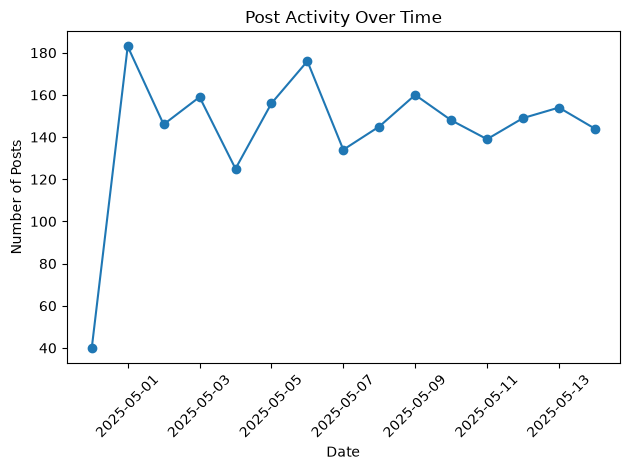

In [74]:
daily_posts.plot(
    kind="line",
    marker="o",
    title="Post Activity Over Time",
    xlabel="Date",
    ylabel="Number of Posts"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

UNDERSTAND POSTS

In [75]:
from collections import Counter
import re

# Combine all post text into one large string
all_text = " ".join(df_posts["text"].astype(str))

# Convert to lowercase
all_text = all_text.lower()

# Extract words
words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9'-]*\b", all_text)

# Count words
word_counts = Counter(words)

# Display the 30 most common words
word_counts.most_common(30)

[('the', 8711),
 ('to', 6767),
 ('and', 5910),
 ('a', 5506),
 ('i', 4914),
 ('it', 3886),
 ('of', 3782),
 ('is', 3347),
 ('for', 3135),
 ('in', 2804),
 ('that', 2692),
 ('with', 2291),
 ('this', 2101),
 ('on', 1967),
 ('ai', 1804),
 ('you', 1746),
 ('or', 1659),
 ('but', 1651),
 ('https', 1431),
 ('not', 1350),
 ('be', 1277),
 ('s', 1217),
 ('are', 1199),
 ('my', 1178),
 ('as', 1172),
 ('if', 1161),
 ('model', 1133),
 ('have', 1098),
 ('can', 1095),
 ('what', 1080)]

In [76]:
Counter(words)

Counter({'the': 8711,
         'to': 6767,
         'and': 5910,
         'a': 5506,
         'i': 4914,
         'it': 3886,
         'of': 3782,
         'is': 3347,
         'for': 3135,
         'in': 2804,
         'that': 2692,
         'with': 2291,
         'this': 2101,
         'on': 1967,
         'ai': 1804,
         'you': 1746,
         'or': 1659,
         'but': 1651,
         'https': 1431,
         'not': 1350,
         'be': 1277,
         's': 1217,
         'are': 1199,
         'my': 1178,
         'as': 1172,
         'if': 1161,
         'model': 1133,
         'have': 1098,
         'can': 1095,
         'what': 1080,
         'like': 1006,
         'just': 928,
         'an': 926,
         'so': 922,
         'models': 904,
         'com': 867,
         'from': 856,
         'at': 815,
         'we': 812,
         'how': 783,
         'was': 782,
         'use': 755,
         'do': 747,
         'by': 740,
         'me': 737,
         'your': 717,
         'ab

In [80]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    min_df=5
)

X = vectorizer.fit_transform(
    df_posts["clean_text"].astype(str)
)

phrases = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

phrase_counts = sorted(
    zip(phrases, counts),
    key=lambda x: x[1],
    reverse=True
)

phrase_counts[:30]

[('llama cpp', np.int64(164)),
 ('open source', np.int64(124)),
 ('30b a3b', np.int64(95)),
 ('tokens second', np.int64(80)),
 ('qwen3 30b', np.int64(76)),
 ('gemini pro', np.int64(73)),
 ('qwen3 235b', np.int64(73)),
 ('gpt 4o', np.int64(71)),
 ('lm studio', np.int64(68)),
 ('235b a22b', np.int64(65)),
 ('qwen3 32b', np.int64(61)),
 ('use ai', np.int64(53)),
 ('deep research', np.int64(51)),
 ('real time', np.int64(50)),
 ('real world', np.int64(50)),
 ('use cases', np.int64(49)),
 ('user input', np.int64(47)),
 ('o4 mini', np.int64(45)),
 ('ai models', np.int64(43)),
 ('use case', np.int64(43)),
 ('don know', np.int64(40)),
 ('language models', np.int64(40)),
 ('local llm', np.int64(40)),
 ('ai agents', np.int64(38)),
 ('kv cache', np.int64(38)),
 ('fine tuning', np.int64(37)),
 ('open ai', np.int64(37)),
 ('prompt eval', np.int64(37)),
 ('let know', np.int64(36)),
 ('sam altman', np.int64(36))]

In [81]:
# Number of posts in each subreddit
subreddit_counts = (
    df_posts["subreddit"]
    .value_counts()
)

print(subreddit_counts)

subreddit
LocalLLaMA     879
OpenAI         675
singularity    401
artificial     203
Name: count, dtype: int64


In [82]:
for subreddit in df_posts["subreddit"].unique():

    subset = df_posts[
        df_posts["subreddit"] == subreddit
    ]

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(2, 2),
        min_df=3
    )

    X = vectorizer.fit_transform(
        subset["clean_text"].astype(str)
    )

    phrases = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1

    phrase_counts = sorted(
        zip(phrases, counts),
        key=lambda x: x[1],
        reverse=True
    )

    print("\n" + "=" * 50)
    print(subreddit)
    print("=" * 50)

    print(phrase_counts[:15])


artificial
[('use ai', np.int64(19)), ('ai news', np.int64(15)), ('daily ai', np.int64(15)), ('minute daily', np.int64(14)), ('ai tools', np.int64(13)), ('real world', np.int64(12)), ('gemini pro', np.int64(11)), ('news 2025', np.int64(9)), ('plot promises', np.int64(9)), ('ai actually', np.int64(8)), ('ai agents', np.int64(8)), ('like ai', np.int64(8)), ('new ai', np.int64(8)), ('using ai', np.int64(8)), ('ai models', np.int64(7))]

LocalLLaMA
[('llama cpp', np.int64(164)), ('30b a3b', np.int64(93)), ('open source', np.int64(89)), ('tokens second', np.int64(80)), ('qwen3 30b', np.int64(74)), ('qwen3 235b', np.int64(70)), ('lm studio', np.int64(68)), ('235b a22b', np.int64(62)), ('qwen3 32b', np.int64(60)), ('m3max lcpp', np.int64(50)), ('rtx3090 lcpp', np.int64(46)), ('local llm', np.int64(40)), ('kv cache', np.int64(37)), ('prompt eval', np.int64(37)), ('llama server', np.int64(34))]

singularity
[('gemini pro', np.int64(20)), ('open source', np.int64(19)), ('deep research', np.int6

Engagement analysis

In [83]:
print(df_posts["score"].describe())

count    2158.000000
mean       46.481001
std       138.375264
min         0.000000
25%         1.000000
50%         5.000000
75%        33.000000
max      2304.000000
Name: score, dtype: float64


In [84]:
print(
    df_posts.groupby("subreddit")["score"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

             count        mean  median   max
subreddit                                   
singularity    401  111.720698    32.0  2304
LocalLLaMA     879   36.418658     6.0   820
OpenAI         675   29.420741     2.0  2188
artificial     203   17.906404     2.0   206


In [85]:
print(
    df_posts.groupby("subreddit")["score"]
    .agg(["mean", "median", "max"])
)

                   mean  median   max
subreddit                            
LocalLLaMA    36.418658     6.0   820
OpenAI        29.420741     2.0  2188
artificial    17.906404     2.0   206
singularity  111.720698    32.0  2304
